In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('..')
from mount_drive import mount_s_drive

ModuleNotFoundError: No module named 'mount_drive'

In [ ]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), 'analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score

In [2]:
myPredictorsDf = pd.read_csv('eICUPredictors.csv')

In [3]:
myPredictorsDf.columns

Index(['patientunitstayid', 'gender', 'age', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource',
       'admissionweight', 'PEA', 'Asystole',
       ...
       'serum ketones', 'Theophylline', 'Pressure Control', 'Vent Other',
       'WBC's in peritoneal fluid', 'Cyclosporin', 'Site', 'Amikacin - peak',
       'PTT ratio', 'Vancomycin - peak'],
      dtype='object', length=228)

In [5]:
bio_columns = ['pH', 'Lactate', 'Chloride']

In [6]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
myFilter = (myPredictorsDf['FirstGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstGCS'].isna()) & (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstMGCS'].isna()) & (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int)
myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(int) == 6).astype(int)

In [10]:
myXValue = myPredictorsDf.drop(columns= ['LastMGCS', 'LastMGCSTime', 'FirstMGCSTime', 'LastMGCSPositive', 'LastGCSPositive', 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(int)
myYValue = myPredictorsDf[myFilter]['LastMGCSPositive']
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['LastMGCSPositive', 'Hypothermia']], test_size=0.4)

In [11]:

def getTreatmentEffectDiffUnsupervised(aX, aY, aGroups, aCategory = 'CPC12', aGroup = 'groupe'):
        if aX.shape[0] != aY.shape[0]:
            raise Exception('Mismatch X and Y')
        if aX.shape[0] != aGroups.shape[0]:
            raise Exception('Mismatch group and X')
        myNewDf = pd.DataFrame()
        myNewDf['predicted_effect_group'] = aGroups
        myData = pd.concat([aX[aGroup], myNewDf['predicted_effect_group'], aX['FirstGCS'], aY], axis=1)
        model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
        ).fit()

        model2 = smf.logit(
        f'{aCategory} ~  predicted_effect_group * {aGroup}',
        data=myData
        ).fit()

        llr = -2*(model1.llf - model2.llf)
        df_diff = model2.df_model - model1.df_model
        p_value = chi2.sf(llr, df_diff)

        print(f'Likelihood ratio of test results:')
        print(f'Chi square statistic: {llr}')
        print(f'p-value: {p_value}')
        print(f'Degress of freedom: {df_diff}')
        print(f'Interaction p-value: {model1.summary()}')
        print(f'Interaction p-value: {model2.summary()}')
        return p_value, model2, myData
def plotPredictedEffectDiff(aData, aBestModel, aCategory = 'CPC12', aGroup = 'groupe'):
    predicted_effect_groups = aData['predicted_effect_group'].unique()
    predicted_effect_groups.sort()
    groupe_values = aData[aGroup].unique()
    groupe_values.sort()
    groupe_values = list(filter(lambda x: not np.isnan(x), groupe_values))
    
    predicted_effect_groups = list(filter(lambda x: x != 'nan', predicted_effect_groups))
    # predicted_effect_groups = [int(i) for i in predicted_effect_groups]

    # Prepare the DataFrame for prediction
    predictions = []
    for groupe in groupe_values:
            for effect in predicted_effect_groups:
                    temp_df = pd.DataFrame({
                            'predicted_effect_group': [effect],
                            # 'FirstGCS': 3,
                            aGroup: [groupe]
                    })
                    # Predict the probability
                    temp_df['predicted_prob'] = aBestModel.predict(temp_df)
                    predictions.append(temp_df)

    # Concatenate all predictions
    predictions_df = pd.concat(predictions)
    
    # Create a bar plot
    plt.figure(figsize=(8, 6))
    for i, groupe in enumerate(groupe_values):
            subset = predictions_df[predictions_df[aGroup] == groupe]
            plt.bar(
                    subset['predicted_effect_group'].astype(float) + (i * 0.2) - 0.1,    # Shift bars slightly for better visualization
                    subset['predicted_prob'],
                    width=0.2,
                    label=f'Groupe {groupe}'
            )
            
    x_positions = np.arange(len(predicted_effect_groups)) 

    plt.xticks(x_positions)
    plt.xlabel('Predicted Effect Group')
    plt.ylabel(f'Predicted Probability of {aCategory}')
    plt.title(f'Predicted Probability of {aCategory} by Predicted Effect Group and Groupe')
    plt.legend(title='Groupe')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
def plotPredictedTreatmentEffect(myNewDf, aCategory = 'CPC12'):
    lower_third, upper_third, myNewDf = getPredictedThirds(myNewDf)
    if lower_third == upper_third:
        plt.scatter(x = range(len(y_pred_proba1)), y = myNewDf['predicted_effect'].sort_values())
    else:
        myNewDf.sort_values(['predicted_effect'], inplace=True)
        myNewDf.reset_index(inplace=True)
        for group in myNewDf['predicted_effect_group']:
            myFilter = myNewDf['predicted_effect_group'] == group
            plt.scatter(x = myNewDf[myFilter]['predicted_effect'].index, y = myNewDf[myFilter]['predicted_effect'])
        plt.legend(myNewDf['predicted_effect_group'].unique())
    plt.title(f'Predicted treatment effect diff between hypothermia and normothermia for {aCategory}')
    return lower_third, upper_third, myNewDf

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fd0d41924c0>
Traceback (most recent call last):
  File "/home/idies/miniconda3/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/idies/miniconda3/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/idies/miniconda3/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/idies/miniconda3/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.mat

Silhouette score of clusters: 0.3432650973970553
Optimization terminated successfully.
         Current function value: 0.638666
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.637380
         Iterations 6
Likelihood ratio of test results:
Chi square statistic: 6.4160595022081
p-value: 0.040436204226022385
Degress of freedom: 2.0
Interaction p-value:                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 2495
Model:                          Logit   Df Residuals:                     2491
Method:                           MLE   Df Model:                            3
Date:                Mon, 27 Jan 2025   Pseudo R-squ.:                 0.04420
Time:                        18:00:19   Log-Likelihood:                -1593.5
converged:                       True   LL-Null:                       -1667.2
Covariance Type:            nonrobust   LLR p-v

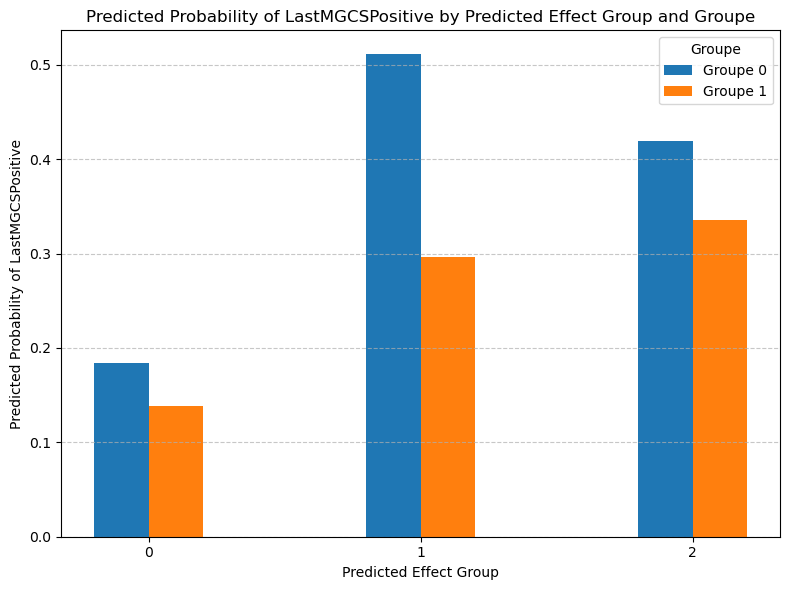

In [12]:
myXInput = myXValue.copy().reset_index()
myClassifierTest = 'LastMGCSPositive'
myYInput = myYValue.copy().reset_index()
myXInput = myXInput.drop(columns=['index'])
myYInput = myYInput.drop(columns=['index'])
myNewXValue = myXInput.copy()
myNewXValue = myNewXValue.drop(columns=['Hypothermia'])
myNewXValue = myNewXValue[['Lactate', 'pH']]
myPipelineSteps = getDefaultPipelineSteps(myNewXValue)
myPipelineSteps.append(('clf', KMeans(n_clusters=3, n_init=10)))
myPipeline = Pipeline(myPipelineSteps)
myGroups = myPipeline.fit_predict(myNewXValue)
# print(myNewXValue)
# print(myGroups)
print(f'Silhouette score of clusters: {silhouette_score(Pipeline(getDefaultPipelineSteps(myNewXValue)).fit_transform(myNewXValue), myGroups)}')
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(myXInput, myYInput, myGroups.astype(str), myClassifierTest, 'Hypothermia')
myData['predicted_effect_group'] = myData['predicted_effect_group'].astype(str)
plotPredictedEffectDiff(aData = myData, aBestModel = myModel, aGroup = 'Hypothermia', aCategory = myClassifierTest)

In [518]:
myGroups.shape

(3233,)